# NNHF

In [9]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2, l1
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, kCrossValSingle
from time import perf_counter
import pandas
import os
seed = 7
np.random.seed(seed)

In [10]:
#########################     TRAIN SET      ##########################
mu_train_HF = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/mu_train_HF_15.txt")
#MIXING
permutation = np.random.permutation(len(mu_train_HF))
mu_train_HF=mu_train_HF[permutation][0:5]
U_hf_train = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/Uhf_train_15.txt")
U_hf_train=U_hf_train[permutation][0:5]
Nhf=np.size(mu_train_HF)
NepoHF = 3000  

In [11]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases/mu_test.txt")
N_test = np.size(mu_test)
#mu_test=build_poly(mu_test,3)
U_hf_test = np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases//Uhf_test.txt")
#U_lf_test = U_lf_test_full[:,m]

In [12]:
########################     NORMALIZATION  #########################
#Input
mu_max = np.max(mu_test,axis=0)
mu_min = np.min(mu_test,axis=0)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_HF_norm = (mu_train_HF - mu_min) / (mu_max - mu_min)


#Output
U_t_max_test=np.max(U_hf_test)
U_t_min_test=np.min(U_hf_test)

U_t_max_train=np.max(U_hf_train)
U_t_min_train=np.min(U_hf_train)

U_hf_train=(U_hf_train-U_t_min_train)/(U_t_max_test-U_t_min_test)
U_hf_test=(U_hf_test-U_t_min_test)/(U_t_max_test-U_t_min_test)

#hfmean = np.mean(U_hf_test)

#U_hf_train = U_hf_train - hfmean
#U_hf_test = U_hf_test - hfmean
start = perf_counter()
#########
mu_final = np.vstack((mu_train_HF_norm))#.transpose() # <- TRAINING INPUT for the second NN: NN_HF
########

In [13]:
##########################       NN_HF     ##########################
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 2
name = 'HF'   # HF has dropout and regularization
K.clear_session()
bayes_trials = Trials()
opt_list = ['Adam','Adamax']
kernel_list = ['uniform','glorot_uniform']
aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
space = {
    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(64),2),
     'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(100)),
     'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
     'kernel_init': hp.choice('kernel_init',kernel_list),
     'opt' : hp.choice('opt',opt_list)}


#opt_list = ['Adam']
#kernel_list = ['uniform']
#aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
#space = {
#    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(16),2),
#     'l2weight' : hp.loguniform('l2weight',np.log(0.1),np.log(100)),
#     'lr': hp.loguniform('lr',np.log(0.01),np.log(0.1)),
#     'kernel_init': hp.choice('kernel_init',kernel_list),
#     'opt' : hp.choice('opt',opt_list)}


def objective(params):
    K.clear_session()
    CVres = kCrossVal(np.shape(mu_final)[1],Nhf,NepoHF,mu_final, U_hf_train,params,name)
    return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

best_params = fmin(fn = objective,
                   space = space,
                   algo = tpe.suggest,
                   max_evals = MAX_EVAL,
                   trials = bayes_trials)

transfBestparam(best_params,aux_dic)
print(best_params)

  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 67ms/step 

1/1 [==============================] - 0s 16ms/step 

1/1 [==============================] - 0s 17ms/step 

1/1 [==============================] - 0s 38ms/step 

1/1 [==============================] - 0s 30ms/step 

1/1 [==============================] - 0s 63ms/step                              

1/1 [==============================] - 0s 25ms/step                              

1/1 [==============================] - 0s 31ms/step                              

1/1 [==============================] - 0s 31ms/step                              

1/1 [==============================] - 0s 26ms/step                              

100%|██████████| 2/2 [02:09<00:00, 64.87s/trial, best loss: 0.0015028825445152177]
{'kernel_init': 'glorot_uniform', 'l2weight': 3.221465603701579, 'lr': 0.00020335038867684018, 'nodes': 30.0, 'opt': 'Adam'}


In [14]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()

finalModel = getModel(best_params,name) #final model chosen according to the best paramters
hist = finalModel.fit(mu_train_HF_norm, U_hf_train, validation_data=(mu_test_norm, U_hf_test),epochs=NepoHF,batch_size=Nhf,verbose=0, validation_freq = 20)

UHF = finalModel.predict(mu_test_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nHF Model:')

elapsed2 = stop - start2
print('Elapsed time: ', elapsed2)
print('\nHF Model:')

test_mse = np.mean(np.square(U_hf_test - UHF[:,0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_hf_test - UHF[:,0])) / np.sum(np.square(U_hf_test - np.mean(U_hf_test)))
print(f"R^2: {r2_HF}")

4/4 [==============================] - 0s 0s/step
Elapsed time:  149.93629059998784

HF Model:
Elapsed time:  19.73225540004205

HF Model:
Test MSE: 0.001442146522780899
R^2: 0.9789852314002285


4/4 [==============================] - 0s 3ms/step


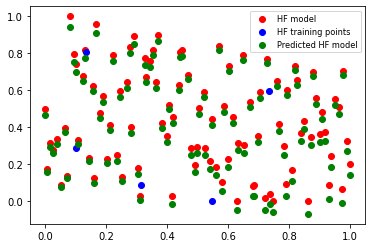

4/4 [==============================] - 0s 0s/step


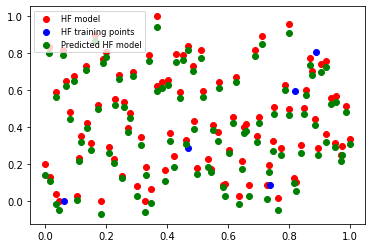

4/4 [==============================] - 0s 5ms/step


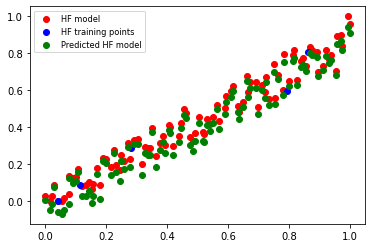

In [15]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.scatter(mu_test_norm[:,0], U_hf_test, color='red', label = 'HF model')
plt.scatter(mu_train_HF_norm[:,0], U_hf_train ,color='blue',label = 'HF training points')
plt.scatter(mu_test_norm[:,0], finalModel.predict(mu_test_norm),color='green', label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

plt.figure()
plt.scatter(mu_test_norm[:,1], U_hf_test, color='red', label = 'HF model')
plt.scatter(mu_train_HF_norm[:,1], U_hf_train ,color='blue',label = 'HF training points')
plt.scatter(mu_test_norm[:,1], finalModel.predict(mu_test_norm),color='green', label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

plt.figure()
plt.scatter(mu_test_norm[:,2], U_hf_test, color='red', label = 'HF model')
plt.scatter(mu_train_HF_norm[:,2], U_hf_train ,color='blue',label = 'HF training points')
plt.scatter(mu_test_norm[:,2], finalModel.predict(mu_test_norm),color='green', label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

In [8]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs('Output_NNHF')

R2_HF=pandas.DataFrame({'R2_HF': [r2_HF]})
#R2_LF=pandas.DataFrame({'R2_LF': [r2_LF]})
#MSE_test_LF=pandas.DataFrame({'MSE_test_LF': [test_mse_LF]})
MSE_test_HF=pandas.DataFrame({'MSE_test_HF': [test_mse]})


#R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv('./Output_NNHF/test_mse.txt', header = True, index = False, sep = '\t', mode = 'a')
R2_HF.to_csv('./Output_NNHF/r2_LF_lhs.txt', header=True, index=False, sep='\t', mode='a')
#MSE_test_LF.to_csv('./Output_NNHF/mse_LF_lhs.txt', header = True, index = False, sep = '\t', mode = 'a')

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'Output_NNHF'